In [1]:
!pip install vedo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 97.0 kB/s  0:00:28 eta 0:00:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 MB 278.5 kB/s  0:07:410:00:0100:14
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [vedo]1/2 [vedo]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [ ]:
def get_coord(d, value):
    for k in d.key():
        if d[k] == value:
            return k

    return None


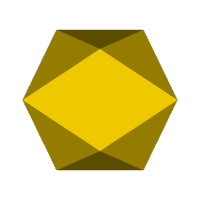

In [ ]:
from vedo import Mesh, show

# Load the mesh and optionally a texture
mesh = Mesh("ico.obj")
# mesh.texture("path/to/your/texture.jpg") # Optional: load texture

# Display the object in an interactive windowmesh)
mesh

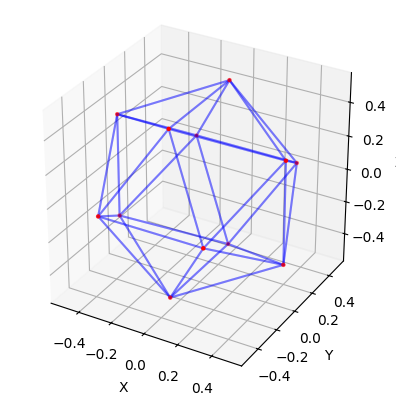

Iteração 1...


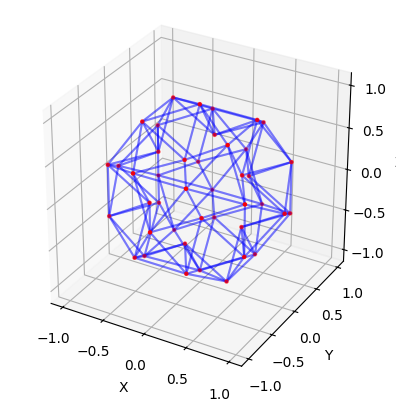

Iteração 2...


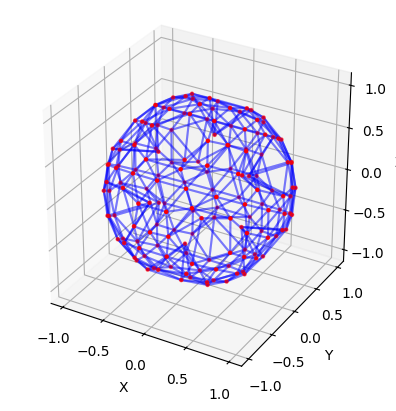

Iteração 3...


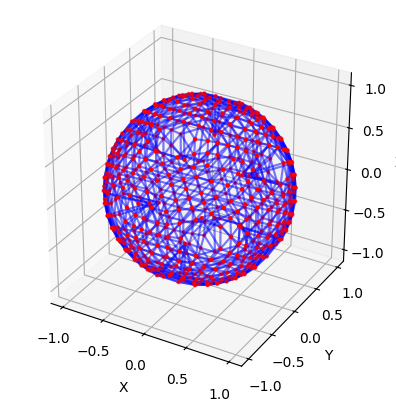

Iteração 4...


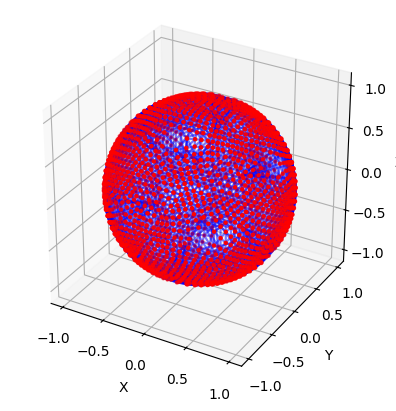

Iteração 5...


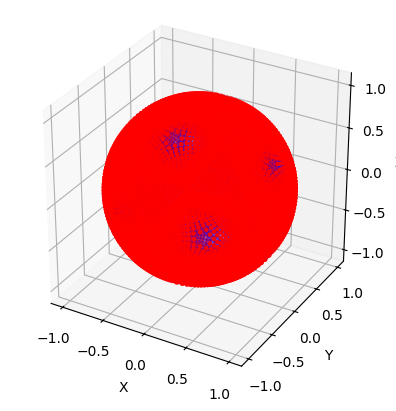

Iteração 6...


KeyboardInterrupt: 

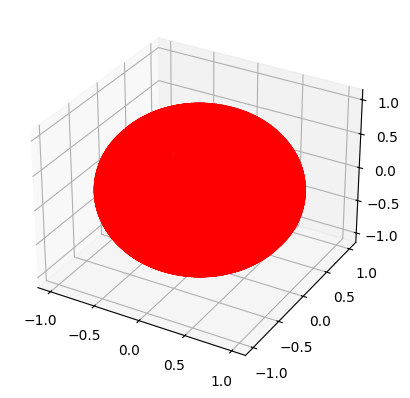

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


class vertex:
    def __init__(self, c: np.ndarray, idx: int = None):
        self.coord = c
        self.index = idx


class obj:
    def __init__(self, V: dict = None, F=None):
        self.vdict = V if V is not None else {}
        self.faces = F if F is not None else []

    def print_obj(self, save=None, path=None):
        fig = plt.figure()
        ax = fig.add_subplot(111, projection="3d")

        vals = list(self.vdict.values())
        x_vals = [v.coord[0] for v in vals]
        y_vals = [v.coord[1] for v in vals]
        z_vals = [v.coord[2] for v in vals]

        ax.scatter(x_vals, y_vals, z_vals, c="r", marker=".")

        if self.faces:
            for face in self.faces:

                v1 = self.vdict[face[0]].coord
                v2 = self.vdict[face[1]].coord
                v3 = self.vdict[face[2]].coord

                ax.plot([v1[0], v2[0]], [v1[1], v2[1]], [v1[2], v2[2]], "b-", alpha=0.3)
                ax.plot([v2[0], v3[0]], [v2[1], v3[1]], [v2[2], v3[2]], "b-", alpha=0.3)
                ax.plot([v3[0], v1[0]], [v3[1], v1[1]], [v3[2], v1[2]], "b-", alpha=0.3)

        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")

        ax.set_box_aspect([1, 1, 1])

        if save:
            plt.savefig(path)
        else:
            plt.show()


def read_obj(path):
    V = {}
    F = []
    count = 0
    with open(path, "r") as f:
        for line in f.readlines():
            if line.startswith("v "):
                count += 1
                parts = line.split()

                V[count] = vertex(
                    np.array([float(parts[1]), float(parts[2]), float(parts[3])]), count
                )
            elif line.startswith("f "):
                parts = line.split()

                idx_a = int(parts[1].split("/")[0])
                idx_b = int(parts[2].split("/")[0])
                idx_c = int(parts[3].split("/")[0])
                F.append((idx_a, idx_b, idx_c))
    return obj(V, F)


def improve_obj(obje: obj):

    new_vdict = obje.vdict.copy()
    new_faces = []

    midpoint_cache = {}

    current_max_id = max(new_vdict.keys()) if new_vdict else 0

    def get_midpoint_index(idx1, idx2):
        nonlocal current_max_id

        edge_key = tuple(sorted((idx1, idx2)))

        if edge_key in midpoint_cache:
            return midpoint_cache[edge_key]

        # Se não, calcula
        c1 = new_vdict[idx1].coord
        c2 = new_vdict[idx2].coord

        mid = (c1 + c2) / 2
        mid = mid / np.linalg.norm(mid)

        current_max_id += 1
        new_vdict[current_max_id] = vertex(mid, current_max_id)

        midpoint_cache[edge_key] = current_max_id

        return current_max_id

    for f in obje.faces:
        v1_idx, v2_idx, v3_idx = f

        a = get_midpoint_index(v1_idx, v2_idx)
        b = get_midpoint_index(v2_idx, v3_idx)
        c = get_midpoint_index(v3_idx, v1_idx)

        f1 = (v1_idx, a, c)
        f2 = (v2_idx, b, a)
        f3 = (v3_idx, c, b)
        f4 = (a, b, c)

        new_faces.extend([f1, f2, f3, f4])

    return obj(new_vdict, new_faces)


def write(path, ob):
    with open(path, "w") as fr:

        for v in sorted(ob.vdict.values(), key=lambda x: x.index):
            fr.write(f"v {v.coord[0]} {v.coord[1]} {v.coord[2]} \n")

        for face in ob.faces:
            fr.write(f"f {face[0]} {face[1]} {face[2]} \n")


try:

    icosaedro = read_obj("ico.obj")

    initial = icosaedro
    initial.print_obj()

    for i in range(10):
        print(f"Iteração {i+1}...")
        initial = improve_obj(initial)
        initial.print_obj()
        write(f"iteracao_{i}.obj", initial)

except FileNotFoundError:
    print("Erro: Arquivo 'ico.obj' não encontrado.")
except Exception as e:
    print(f"Ocorreu um erro: {e}")

In [3]:
print(len(icosaedro.vlist))

AttributeError: 'obj' object has no attribute 'vlist'

In [7]:
!pip install open3d

  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached fastjsonschema-2.21.2-py3-none-any.whl.metadata (2.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━ 301.7/447.7 MB 336.7 kB/s eta 0:07:14
Resuming download open3d-0.19.0-cp312-cp312-manylinux_2_31_x86_64.whl (301.7 MB/447.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 489.2 kB/s  0:08:350:00:0100:38
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 284.1 kB/s  0:00:28m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 803.4 kB/s  0:00:01ta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 409.9 kB/s  0:00:04 eta 0:00:01
Using cached nbformat-5.10.4-py3-none-any.whl (78 kB)
Using cached fastjsonschema-2.21.2-py3-none-any.whl (24 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 261.8 kB/s  0:00:45m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 268.8 kB/s  0:00:02eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import open3d as o3d
import numpy as np


# 1. Extract coordinates from your icosahedron object
# We use a list comprehension for cleaner, faster code
points = np.array(
    [
        v.coord
        for v in improve_obj(
            improve_obj(improve_obj(improve_obj(improve_obj(read_obj("ico.obj")))))
        ).vdict.values()
    ]
)

# 2. Create an Open3D point cloud object
pcd = o3d.geometry.PointCloud()

# Assign the numpy array directly to the Open3D vector
pcd.points = o3d.utility.Vector3dVector(points)

# Optional: color the vertices (e.g., Red) for better visibility
# Creates an array of [1, 0, ac0] of the same length as 'points'
colors = np.tile([1.0, 0.0, 0.0], (len(points), 1))
pcd.colors = o3d.utility.Vector3dVector(colors)

# 3. Visualize
print(f"Visualizing {len(points)} vertices. Press 'q' to close window.")

# Adding a coordinate frame helps to see orientation (Red=X, Green=Y, Blue=Z)
axis = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.2, origin=[0, 0, 0])

o3d.visualization.draw_geometries([pcd, axis])

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Visualizing 10242 vertices. Press 'q' to close window.
[Open3D WARNING] GLFW Error: Wayland: The platform does not support setting the window position
[Open3D WARNING] Failed to initialize GLEW.
[Open3D WARNING] [DrawGeometries] Failed creating OpenGL window.


libdecor-gtk-WARNING: Failed to initialize GTK
Failed to load plugin 'libdecor-gtk.so': failed to init
No plugins found, falling back on no decorations


In [ ]:
import open3d as o3d
import numpy as np
import time


# --- Helper to convert your 'obj' class to an Open3D LineSet ---
def obj_to_lineset(my_obj):
    # 1. Vertices
    points = np.array([v.coord for v in my_obj.vdict.values()])

    # 2. Edges (derived from Faces)
    # We use a set to avoid duplicate edges for cleaner rendering
    edges = set()
    for f in my_obj.faces:
        # Convert 1-based index to 0-based
        idx = [i - 1 for i in f]
        # Sort indices to ensure (0,1) is same as (1,0)
        edges.add(tuple(sorted((idx[0], idx[1]))))
        edges.add(tuple(sorted((idx[1], idx[2]))))
        edges.add(tuple(sorted((idx[2], idx[0]))))

    lines_indices = list(edges)

    # 3. Create Open3D Geometry
    line_set = o3d.geometry.LineSet()
    line_set.points = o3d.utility.Vector3dVector(points)
    line_set.lines = o3d.utility.Vector2iVector(lines_indices)

    # Make it Black
    line_set.paint_uniform_color([0, 0, 0])
    return line_set


# --- 1. Pre-calculate the Frames ---
print("Generating frames...")
frames = []
current_obj = read_obj("ico.obj")  # Load your initial icosahedron

# Add the starting shape
frames.append(obj_to_lineset(current_obj))

# Calculate 4 more levels of refinement
for i in range(6):
    current_obj = improve_obj(current_obj)
    frames.append(obj_to_lineset(current_obj))
    print(f"Generated frame {i+1} with {len(current_obj.vdict)} vertices")

# --- 2. Setup the Visualizer ---
vis = o3d.visualization.Visualizer()
vis.create_window(window_name="Sphere Refinement Animation", width=800, height=600)

# Add the first frame to initialize the view
current_geometry = frames[0]
vis.add_geometry(current_geometry)

# --- 3. Run the Animation Loop ---
print("Starting animation...")
frame_idx = 0
last_switch_time = time.time()

while True:
    # Check if window is closed
    if not vis.poll_events():
        break

    vis.update_renderer()

    # Switch frames every 1 second
    if time.time() - last_switch_time > 1.0:

        # 1. Remove the old shape (keep camera steady with reset_bounding_box=False)
        vis.remove_geometry(current_geometry, reset_bounding_box=False)

        # 2. Advance to next frame (loop back to 0 if at end)
        frame_idx = (frame_idx + 1) % len(frames)
        current_geometry = frames[frame_idx]

        # 3. Add the new shape
        vis.add_geometry(current_geometry, reset_bounding_box=False)

        print(f"Showing Level {frame_idx}")
        last_switch_time = time.time()

vis.destroy_window()

Generating frames...
Generated frame 1 with 42 vertices
Generated frame 2 with 162 vertices
Generated frame 3 with 642 vertices
Generated frame 4 with 2562 vertices
Generated frame 5 with 10242 vertices
